<a href="https://colab.research.google.com/github/Loicsav/SalasOrtegaConde/blob/main/Entornos_Complejos/DiferenciaTemporal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Metodos Aproximados**

_Esto es un ejemplo de uso de Gymnasium e informe sobre un experimento de aprendizaje por refuerzo_

````
Luis D. Hernández.
<ldaniel at um.es>
````

Este notebook describe un experimento de aprendizaje por refuerzo utilizando el algoritmo de Monte Carlo con políticas epsilon-soft. El propósito de este análisis es entrenar un agente en un entorno de gym con el juego "FrozenLake", un entorno estándar en el que el agente debe aprender a moverse a través de un mapa en busca de una meta, evitando caer en agujeros. A continuación, se presenta una descripción de las diferentes partes del código y el proceso utilizado en el experimento.

🎯 **Ojo, el código debe modificarse para ser un auténtico Monte Carlo. Supongo que sabrás darte cuenta.**

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "FrozenLake"**:
Se cargan dos versiones del entorno "FrozenLake": una de 4x4 y otra de 8x8. Ambas versiones no son resbaladizas, lo que facilita la comprensión de los resultados, dado que el entorno resbaladizo podría dificultar la comprensión inicial del aprendizaje.

#### 3. **Funciones para Mostrar los Resultados**
   - Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### **Código de la Instalación e Importación**
----

%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
#!apt install swig
#!pip install gymnasium[box2d]


# Instalación de algunos paquetes.
!apt-get update

# Para visualizar en colab https://medium.com/@coldstart_coder/visually-rendering-python-gymnasium-in-jupyter-notebooks-4413e4087a0f
!apt-get install -y python-opengl ffmpeg
!apt-get install --upgrade cmake

# Para usar gymnasium[box2d]
!apt install swig xvfb
!pip install -U  pyvirtualdisplay

!pip install gymnasium gymnasium[box2d]

In [2]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc

from src.agents.AgenteDT_SarsaSG import AgenteDT_SarsaSG
from src.agents.AgenteDT_Deep_QL import AgenteDT_DobleDeepQL

from src.tilings.tiling import TileCodingEnv

from src.ploting import *

In [3]:
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

Usando dispositivo: cpu


In [4]:
#@title Importamos el lago helado
video_folder = "./videos"  # Asegúrate de que esta ruta coincide con la carpeta donde se guardan los videos
name = 'MountainCar-v0'
render = "rgb_array"
env = gym.make(name, render_mode=render, max_episode_steps=200 )

In [5]:
#@title Generamos 4 mosaicos (tilings) con 20x20 intervalos. Al nuevo espacio lo llamaremos *tcenv*
tilings = 10
bins = np.array([20, 20])
low = env.observation_space.low
high = env.observation_space.high
tcenv = TileCodingEnv(env, bins=bins, low=low, high=high, seed=seed, n=tilings)
print("Se muestran los 4 mosáicos")
tcenv.tilings

Se muestran los 4 mosáicos


[[array([-1.0783054 , -0.97971815, -0.88113093, -0.78254366, -0.6839565 ,
         -0.5853692 , -0.486782  , -0.3881948 , -0.28960758, -0.19102037,
         -0.09243315,  0.00615406,  0.10474133,  0.20332849,  0.30191576,
          0.40050292,  0.4990902 ,  0.59767747,  0.6962646 ], dtype=float32),
  array([-0.06126451, -0.05328593, -0.04530735, -0.03732878, -0.0293502 ,
         -0.02137161, -0.01339304, -0.00541446,  0.00256412,  0.01054271,
          0.01852129,  0.02649987,  0.03447844,  0.04245702,  0.0504356 ,
          0.05841418,  0.06639276,  0.07437134,  0.08234992], dtype=float32)],
 [array([-1.108764  , -1.0068988 , -0.9050334 , -0.80316806, -0.70130277,
         -0.5994375 , -0.49757212, -0.39570677, -0.29384148, -0.19197619,
         -0.0901109 ,  0.01175451,  0.1136198 ,  0.2154851 ,  0.3173505 ,
          0.4192158 ,  0.5210811 ,  0.6229464 ,  0.7248116 ], dtype=float32),
  array([-0.06130239, -0.05307075, -0.0448391 , -0.03660745, -0.0283758 ,
         -0.02014415, -0.

## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
   - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad de ser elegida.
   - **Política epsilon-greedy**: basada en la política epsilon-soft. De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
   - **Política greedy**: Es la usada una vez que "ha aprendido".

- **Algoritmo de Iteración de Valor**
  - Se implementa el algoritmo de iteración de valor utilizando Monte Carlo.
  - Se usa una versión "on-policy" de Monte Carlo con políticas epsilon greedy sobre una política epsilon-soft.
  - Se basa en el criterio de todas las visitas.
  - Otro aspecto es que la actualización de los retornos no se realiza en el orden inverso a las visitas.

#### **Código de las políticas y algoritmo MC**
----------------

In [5]:
#@title Algoritmo de Iteración de Valor versión MC con Políticas epsilon-soft

def diferencia_temporal(tcenv, agente, num_episodes=5000):
    stats = 0.0
    list_stats = [stats]
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes)):
        state, info = tcenv.reset(seed=seed)
        done = False
        episode = []
        result_sum  = 0.0
        action = agente.get_action(state, t)
        while not done:
            new_state, reward, done, _, _ = tcenv.step(action)
            new_action = agente.get_action(new_state, t)
            # Guardamos el estado, la acción y la recompensa INMEDIATA
            episode.append((state, action, reward))
            agente.update(state, action, reward, new_state, new_action, done)
            result_sum += reward
            state = new_state
            action = new_action

        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}, Alpha: {agente.alpha:.3f}")

    return list_stats, all_episode_lengths


## **3. Experimentación**

   - En esta sección, el algoritmo de Monte Carlo con la política epsilon (decaimiento) se ejecuta tanto para el entorno de 4x4 como al de 8x8 de FrozenLake sin resbalar.
   
   - En ambos casos se realiza un entrenamiento con un número determinado de episodios (5000 en concreto)

   - Además en el escenario 8x8 el  epsilon tiene decaimiento de acuerdo a la expresión: $\epsilon = min(1.0, 1000.0/(t+1))$

   - Durante el entrenamiento hay una visualización de la proporción de recompensas obtenidas a lo largo del entrenamiento.

   - Junto a dicho volcado se muestra gráficamente la proporcion de recompensas obtendias.

   - También se hace un volcado de los valores Q de cada estado, donde se muestra cómo el agente valora diferentes acciones en distintos estados del entorno, lo que puede interpretarse como su conocimiento sobre las mejores estrategias para alcanzar la meta sin caer en los agujeros.

   - Además, se muestra la política óptima derivada de los valores Q. Esta política es la que el agente seguiría si tuviera que elegir siempre la acción que maximiza su recompensa esperada.

   

### **3.1 Repressentaciones Gráficas**

Para comprobar el aprendizaje se mostrará la función $f(t)=\frac{\sum_{i=1}^t R_i}{t}$ para $t=1,2,\ldots, NumeroEpisodios$. La justificación es la siguiente. Como sabemmos que el retorno en el estados inicial 1 (pues no hay descuento) o 9, si se divide por el número de episodios ejecutados se calcular el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, nos dirá el porcentaje de veces que el agente ha llegado al estado terminal.


### **3.2 Experimentación en el escenario 4x4**



   - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante




#### **3.2.1 Algoritmo de SARSA**

In [ ]:
# @title Aprendizaje
agente_DT_Sarsa_V4 = AgenteDT_SarsaSG(tcenv, seed, discount_factor=0.99, epsilon=0.25, decay=True, num_episodes=10000, decay_rate=1000.0)
list_stats, all_episode_lengths = diferencia_temporal(tcenv, agente=agente_DT_Sarsa_V4, num_episodes=10000)

Mostramos plots

In [ ]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
plot_lengths(all_episode_lengths)
print(f"Máxima proporcion: {list_stats[-1]}")

Mostramos escenario

In [ ]:
# Crear el entorno de CartPole con render_mode configurado para capturar imágenes.
env_demo = gym.make(name, render_mode='rgb_array')
tilings = 4
bins = np.array([20, 20])
low = env_demo.observation_space.low
high = env_demo.observation_space.high
tcenv_demo = TileCodingEnv(env_demo, bins=bins, low=low, high=high, seed=seed, n=tilings)


# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy(tcenv_demo, agente_DT_Sarsa_V4.action_values_Q, max_steps=500)

# Cerrar el entorno una vez terminado el episodio.
tcenv_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="cartpole_sarsa.gif")
print("GIF guardado en:", gif_path)

In [ ]:
def display_gif2(gif_path):
    """
    Muestra un GIF en Google Colab.

    Parámetros:
      - gif_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML que contiene el GIF incrustado.
    """
    # Abrir el archivo GIF en modo binario.
    with open(gif_path, 'rb') as f:
        video = f.read()
    # Convertir el contenido del GIF a una cadena Base64.
    b64 = base64.b64encode(video)
    # Retornar el objeto HTML que muestra el GIF.
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" style="border: 2px solid black;">')
display_gif2(gif_path)

Mostramos video

#### **3.2.1 Algoritmo de Deep Q-Learning**

In [6]:
from tqdm import tqdm

#@title Algoritmo de Iteración de Deep Q-Learning con Redes Neuronales
def entrenamientoDeepQL(tcenv, agente, num_episodes=5000, target_update_freq=500):
    stats = 0.0
    list_stats = [stats]
    all_episode_lengths = [] 
    step_display = max(1, num_episodes // 10)
    
    global_step = 0 # Añadimos un contador global de pasos
    
    for t in tqdm(range(num_episodes)):
        # Asumo que `seed` está definida globalmente en tu script
        state, info = tcenv.reset() 
        done = False
        episode = []
        result_sum  = 0.0
        c = 0
        
        while not done:
            action = agente.get_action(state, t)
            new_state, reward, terminated, truncated, _ = tcenv.step(action)
            done = truncated or terminated
            
            # Guardamos la experiencia
            episode.append((state, action, reward))
            agente.save_experience(state, action, reward, new_state, done)
            
            # --- EL CAMBIO CRÍTICO: ENTRENAR DENTRO DEL BUCLE ---
            # Ahora la red aprende en cada paso (o cuando el batch tenga tamaño suficiente)
            if global_step % 4 == 0:
                agente.update()
            
            # --- ACTUALIZACIÓN DE RED OBJETIVO POR PASOS ---
            if global_step % target_update_freq == 0 and global_step > 0:
                agente.update_target_network()
            
            result_sum += reward
            state = new_state
            c += 1
            global_step += 1
            
        # Guardamos datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}")

    return list_stats, all_episode_lengths

In [7]:
# @title Aprendizaje
agente_DT_QL_V4 = AgenteDT_DobleDeepQL(tcenv, seed, discount_factor=0.99, epsilon=0.4, decay=True, num_episodes=5000, decay_rate=1000.0)
list_stats, all_episode_lengths = entrenamientoDeepQL(tcenv, agente=agente_DT_QL_V4, num_episodes=5000)

 10%|█         | 502/5000 [01:43<16:58,  4.42it/s]

Episode: 500, Avg Return: -192.80, Epsilon: 0.400


 20%|██        | 1001/5000 [03:29<13:05,  5.09it/s]

Episode: 1000, Avg Return: -193.48, Epsilon: 0.400


 30%|███       | 1501/5000 [05:12<10:48,  5.40it/s]

...

 80%|████████  | 4001/5000 [13:57<03:10,  5.26it/s]

Episode: 4000, Avg Return: -189.55, Epsilon: 0.250


 90%|█████████ | 4502/5000 [15:39<01:35,  5.20it/s]

Episode: 4500, Avg Return: -187.74, Epsilon: 0.222


100%|██████████| 5000/5000 [17:14<00:00,  4.83it/s]


Mostramos graficas

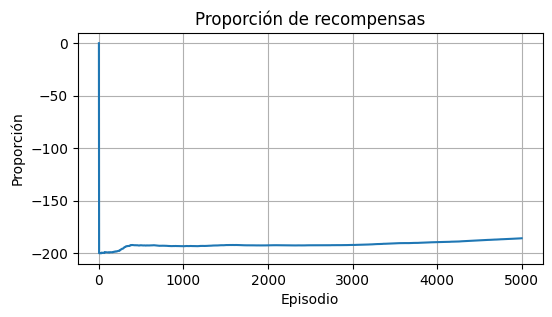

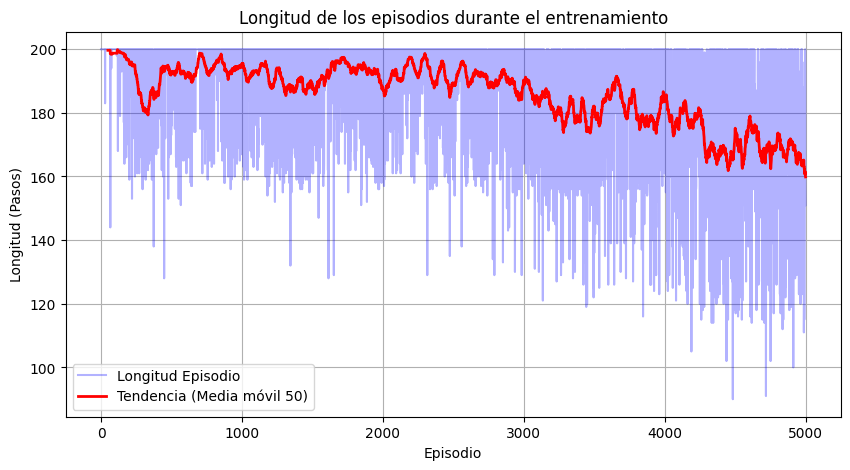

Máxima proporcion: -185.762


In [8]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
plot_lengths(all_episode_lengths)
print(f"Máxima proporcion: {list_stats[-1]}")

Mostramos escenario

In [ ]:
# Crear el entorno de CartPole con render_mode configurado para capturar imágenes.
env_demo = gym.make(name, render_mode='rgb_array')
tilings = 10
bins = np.array([20, 20])
low = env_demo.observation_space.low
high = env_demo.observation_space.high
tcenv_demo = TileCodingEnv(env_demo, bins=bins, low=low, high=high, seed=seed, n=tilings)


# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = run_episode_greedy(tcenv_demo, agente_DT_QL_V4.targetNetwork, max_steps=500, tipo_algoritmo="QNetwork", device=agente_DT_QL_V4.device)

# Cerrar el entorno una vez terminado el episodio.
tcenv_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="cartpole_ql.gif")
print("GIF guardado en:", gif_path)

GIF guardado en: cartpole_ql.gif



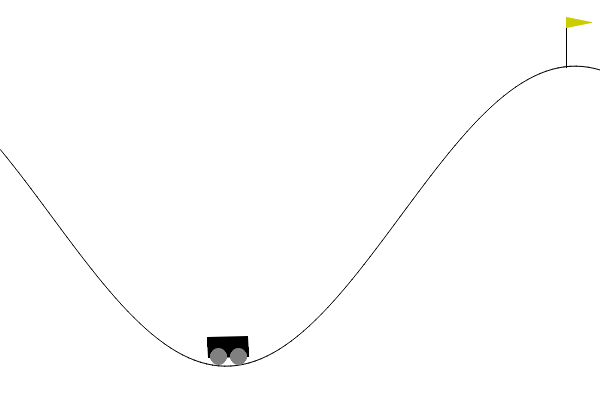

In [16]:
def display_gif2(gif_path):
    """
    Muestra un GIF en Google Colab.

    Parámetros:
      - gif_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML que contiene el GIF incrustado.
    """
    # Abrir el archivo GIF en modo binario.
    with open(gif_path, 'rb') as f:
        video = f.read()
    # Convertir el contenido del GIF a una cadena Base64.
    b64 = base64.b64encode(video)
    # Retornar el objeto HTML que muestra el GIF.
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" style="border: 2px solid black;">')
display_gif2(gif_path)

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- En los dos entornos (4x4 y 8x8), el agente comienza con un conocimiento muy limitado, pero gradualmente mejora su desempeño a medida que avanza en los episodios. Este comportamiento se puede observar en el gráfico de la proporción de recompensas, que aumenta con el tiempo.
- En el entorno 4x4, la máxima proporción de éxito alcanzada fue 0.522, mientras que en el entorno 8x8, la máxima alcanzada fue 0.914. Esto refleja que el agente aprendió a optimizar su estrategia en un entorno más complejo.
- La política óptima obtenida muestra las acciones recomendadas por el agente en cada estado del entorno. En el entorno 8x8, la política es más compleja debido a la mayor cantidad de estados y la dificultad del entorno.

### **4.2 Propuestas para Estudios Futuros**

1. **Evaluar con Otros Entornos**: Sería interesante aplicar este algoritmo a otros entornos más complejos de `gym`, como "Taxi-v3" o "MountainCar", para analizar cómo se comporta el agente en situaciones con dinámicas más complicadas.
   
2. **Optimización del Decaimiento de Epsilon**: Aunque se utilizó un decaimiento de epsilon en el segundo experimento, se podría investigar la efectividad de diferentes tasas de decaimiento o incluso explorar algoritmos como `Q-learning` para comparar su desempeño. Graficamente se trataría de mostrar la curva de la tasa de aciertos para distintas funciones de decaimientos

3. **Análisis del Impacto de los descuentos en las Recompensas**: El estudio se ha hecho para $\gamma = 1$; pero no se ha probado qué pasa cuando  $0 \leq \gamma < 1$. Se trataría de estudiar la curva para distintos valores de $\gamma$

4. **Nuevas gráficas**: Aquí solo se ha usado la proporción de aciertos, pero sería interesante qué relación entre dicha tasa y las tamaños de los episodios.

4. **Ampliación del Algoritmo**: Explorar otros enfoques de Monte Carlo o incluso combinar Monte Carlo con otros algoritmos de aprendizaje por refuerzo, como el Deep Q-Network (DQN), podría mejorar aún más los resultados en entornos más complejos.
